# **🐖 Pig Posture Recognition using Transfer Learning (PyTorch)**

This notebook presents a **complete, end-to-end deep learning pipeline**
for the **Pig Posture Recognition** challenge on Kaggle.


## 📌 Problem Overview

Each image may contain **multiple pigs**.
For every pig, a **bounding box** is provided.

The task is to **classify the posture of each pig independently**
into one of the following five classes:

- Lateral lying (Left)
- Lateral lying (Right)
- Sitting
- Standing
- Sternal lying

The model operates at the **pig level**, not the image level.


## 🧠 Key Techniques Used

- Pig-level classification using bounding-box cropping
- Transfer Learning with **ResNet18 & ResNet50**
- Stratified train–validation split
- Class imbalance handling using **Focal Loss**
- Test-Time Augmentation (TTA)
- Model ensembling
- Qualitative visualization on test images


## 🎯 Objective

To **maximize Macro F1-score** while ensuring:

- Reproducibility
- Correct handling of posture semantics
- Kaggle GPU efficiency


## **📦 Imports & Library Setup**

This section imports all libraries required for the complete pipeline, including:

- File handling and randomness control  
- Data manipulation with NumPy and Pandas  
- Deep learning with PyTorch  
- Computer vision utilities from torchvision  
- Evaluation metrics for Macro F1-score  
- Visualization tools for qualitative analysis  

All libraries are fully compatible with the Kaggle execution environment.


In [1]:
# Standard Libraries
import os
import ast
import random

# Data Handling
import numpy as np
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Computer Vision
from torchvision import transforms, models
from PIL import Image

# Evaluation
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## **⚙️ Device Setup & Reproducibility**

This section configures the execution device and ensures reproducible results.

### Device Selection
- Automatically uses **GPU (CUDA)** when available
- Falls back to **CPU** otherwise
- Ensures the notebook runs consistently across Kaggle environments

### Reproducibility
Random seeds are fixed for:
- Python
- NumPy
- PyTorch (CPU and CUDA)

This guarantees consistent behavior across multiple runs and fair comparison
of experimental results.

In [2]:
# Device Configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

Using device: cuda


## **🐷 Pig Posture Class Mapping**

Pig postures are represented in the dataset using **numeric class IDs**.
For better interpretability, these IDs are mapped to **human-readable labels**.

⚠️ Important:
Some postures encode **left/right orientation**, so horizontal flipping must
be handled carefully later in the pipeline.

This mapping is used consistently for:
- Training and evaluation
- Prediction decoding
- Visualization on test images


In [3]:
# Class Mapping
CLASS_NAMES = {
    0: "Lateral lying (Left)",
    1: "Lateral lying (Right)",
    2: "Sitting",
    3: "Standing",
    4: "Sternal lying"
}

NUM_CLASSES = len(CLASS_NAMES)
print("Number of posture classes:", NUM_CLASSES)

Number of posture classes: 5


## **🧩 Custom Dataset Definition**

A custom PyTorch `Dataset` is implemented to enable **pig-level posture classification**.

### Dataset Design
- Each row in the CSV corresponds to **one pig**
- The full image is loaded from disk
- The pig is cropped using the provided **bounding box**
- Image transformations are applied
- The dataset supports:
  - **Training mode** → returns `(image, class_id)`
  - **Inference mode** → returns `image` only

This design ensures the model learns from **individual pig appearances**
rather than entire images.


In [4]:
# Updated Custom Dataset
class PigPostureDataset(Dataset):
    def __init__(self, csv_file=None, df=None, img_dir=None, transform=None, train=True):
        """
        Args:
            csv_file (str): Path to CSV file (optional)
            df (pd.DataFrame): Pre-loaded dataframe (optional)
            img_dir (str): Directory containing images
            transform (callable): Image transformations
            train (bool): Training or inference mode
        """
        if df is not None:
            self.df = df.reset_index(drop=True)
        else:
            self.df = pd.read_csv(csv_file)

        self.img_dir = img_dir
        self.transform = transform
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = os.path.join(self.img_dir, row["image_id"])
        img = Image.open(img_path).convert("RGB")

        x, y, w, h = map(int, ast.literal_eval(row["bbox"]))
        img = img.crop((x, y, x + w, y + h))

        if self.transform:
            img = self.transform(img)

        if self.train:
            return img, int(row["class_id"])
        else:
            return img

## **🔄 Image Transformations**

Separate transformations are defined for **training** and **testing**.

### Training Transformations
- Resize to model input size
- Apply mild geometric and color augmentations
- Improve generalization without altering posture semantics

### Testing Transformations
- Deterministic preprocessing only
- No augmentation
- Ensures stable and reproducible predictions

⚠️ Horizontal flipping is intentionally avoided because some classes
represent **left/right orientation**.


In [5]:
# Training Transforms
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Test / Inference Transforms
test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## **📁 Dataset Paths, Initialization & DataLoader**

In this section, the dataset paths are defined and the custom dataset is
instantiated using the previously defined transformations.

A PyTorch `DataLoader` is then created to:
- Batch pig-level samples
- Shuffle training data
- Efficiently feed data to the GPU

This step connects the raw data to the training pipeline.

In [6]:
# Dataset paths
BASE = "/kaggle/input/pig-posture-recognition/pig_posture_recognition"

TRAIN_CSV = f"{BASE}/train.csv"
TEST_CSV  = f"{BASE}/test.csv"

TRAIN_IMG_DIR = BASE + "/train_images"
TEST_IMG_DIR  = BASE + "/test_images"

In [7]:
# Training Dataset
train_ds = PigPostureDataset(
    csv_file=TRAIN_CSV,
    img_dir=TRAIN_IMG_DIR,
    transform=train_tfms,
    train=True
)
print("Total pig samples (training CSV):", len(train_ds))

Total pig samples (training CSV): 16062


In [8]:
# Training DataLoader
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=False
)

In [9]:
# Sanity check
imgs, labels = next(iter(train_loader))
print("Images batch shape:", imgs.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([32, 3, 224, 224])
Labels batch shape: torch.Size([32])


## **🧪 Stratified Train–Validation Split**

To evaluate generalization performance, the training data is split into
**training** and **validation** sets using **stratified sampling**.

### Why Stratification?
- Preserves class distribution
- Ensures fair Macro F1-score evaluation
- Prevents rare-class collapse

⚠️ The validation set is **never used for training**.


In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

# Load full training CSV
full_df = pd.read_csv(TRAIN_CSV)

print("Total samples in full training CSV:", len(full_df))


Total samples in full training CSV: 16062


In [11]:
# Stratified Train / Validation Split
splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, val_idx in splitter.split(full_df, full_df["class_id"]):
    train_df = full_df.iloc[train_idx].reset_index(drop=True)
    val_df   = full_df.iloc[val_idx].reset_index(drop=True)

print("Train split size:", len(train_df))
print("Validation split size:", len(val_df))

Train split size: 12849
Validation split size: 3213


In [12]:
train_ds = PigPostureDataset(
    df=train_df,
    img_dir=TRAIN_IMG_DIR,
    transform=train_tfms,
    train=True
)

In [13]:
val_ds = PigPostureDataset(
    df=val_df,
    img_dir=TRAIN_IMG_DIR,
    transform=test_tfms,
    train=True
)

In [14]:
val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

## **⚖️ Class Weights for Imbalance Handling**

Pig posture classes are **not evenly distributed** in the dataset.
Since the competition metric is **Macro F1-score**, each class must contribute
equally to the optimization objective.

To address this imbalance:
- Class frequencies are computed **only from the training split**
- Inverse-frequency class weights are calculated
- These weights are later integrated into the loss function

⚠️ Validation data is intentionally excluded to avoid bias.


In [15]:
# Compute Class Weights (TRAIN SPLIT ONLY)
train_labels = train_df["class_id"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

print("Class weights:", class_weights)

Class weights: tensor([1.5197, 1.3611, 6.8528, 0.4774, 0.7317], device='cuda:0')


## **🔥 Loss Function — Focal Loss**

Standard Cross-Entropy Loss often underperforms on **class-imbalanced datasets**.
To better optimize **Macro F1-score**, **Focal Loss** is used.

### Why Focal Loss?
- Down-weights easy (well-classified) examples
- Focuses learning on hard and rare samples
- Works effectively with class-weighted objectives

The class weights computed from the training split are incorporated directly
into the loss function.


In [16]:
# Focal Loss Definition
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(
            weight=alpha,
            reduction="none"
        )

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


In [17]:
# Initialize Criterion
criterion = FocalLoss(
    alpha=class_weights,
    gamma=2.0
)

print("Focal Loss initialized.")


Focal Loss initialized.


In [18]:
# Sanity check
dummy_logits = torch.randn(8, NUM_CLASSES).to(device)
dummy_targets = torch.randint(0, NUM_CLASSES, (8,)).to(device)

loss_val = criterion(dummy_logits, dummy_targets)
print("Dummy loss value:", loss_val.item())

Dummy loss value: 3.3268682956695557


## **🧠 Model Architecture & Transfer Learning**

Two convolutional neural networks are used:

- **ResNet18** — lightweight, fast convergence
- **ResNet50** — deeper model with richer representations

Both models are initialized with **ImageNet pretrained weights** and adapted
for pig posture classification.

### Fine-Tuning Strategy
- Early layers are frozen to preserve generic visual features
- Higher layers (`layer3`, `layer4`, `fc`) are unfrozen
- Balances learning capacity and overfitting risk


In [19]:
# Model Preparation
def prepare_model(model_name):
    model = getattr(models, model_name)(weights="DEFAULT")

    # Replace final classification layer
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    model = model.to(device)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze higher layers
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True

    return model


In [20]:
# Initialize Models
model18 = prepare_model("resnet18")
model50 = prepare_model("resnet50")

print("ResNet18 and ResNet50 initialized.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 232MB/s]


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


ResNet18 and ResNet50 initialized.


In [21]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable params (ResNet18):", count_trainable_params(model18))
print("Trainable params (ResNet50):", count_trainable_params(model50))

Trainable params (ResNet18): 10496005
Trainable params (ResNet50): 22073349


## **⚙️ Optimizers & Learning Rate Strategy**

Different learning dynamics are used for the two models due to their depth.

### Optimizer Choice
**AdamW** is selected because it:
- Decouples weight decay from gradient updates
- Provides better generalization than Adam
- Is widely used for transfer learning

### Learning Rate Design
- **ResNet18** (shallower) → higher learning rate
- **ResNet50** (deeper) → lower learning rate for stability

A cosine annealing schedule is applied to smoothly decay learning rates
across epochs.


In [22]:
# Optimizers
optimizer18 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model18.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

optimizer50 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model50.parameters()),
    lr=3e-5,
    weight_decay=1e-4
)

In [23]:
# Learning Rate Schedulers
scheduler18 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer18,
    T_max=10
)

scheduler50 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer50,
    T_max=10
)

print("Optimizers and schedulers initialized.")


Optimizers and schedulers initialized.


## **🏋️ Training Loop**

This section defines the training logic for one epoch.

### Training Process
For each batch:
1. Images and labels are moved to the selected device
2. Forward pass through the model
3. Loss computation using Focal Loss
4. Backpropagation
5. Optimizer step

At the end of each epoch:
- Average loss is computed
- **Macro F1-score** is calculated on the entire training set

This function is reused for both ResNet18 and ResNet50.


In [24]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_f1

## **🧪 Validation Loop**

The validation loop evaluates how well the model generalizes to unseen data.

### Key Principles
- Runs with `model.eval()` to disable training behavior
- Uses `torch.no_grad()` to save memory and prevent gradient updates
- Computes **Macro F1-score** on the validation set

Validation results are used only for monitoring and model selection.
They do **not** influence training.


In [25]:
def validate_one_epoch(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds, average="macro")
    return val_f1

## **🚀 Training & Validation Driver**

This section runs the full training process for both models.

### Training Strategy
- Each epoch consists of:
  - Training on the training split
  - Validation on the validation split
- Macro F1-score is reported for both
- Learning rate schedulers are stepped once per epoch

This setup enables transparent monitoring of learning progress
and prevents silent overfitting.


In [26]:
# Training Configuration
NUM_EPOCHS = 10

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    # Train
    train_loss18, train_f118 = train_one_epoch(
        model18, train_loader, optimizer18, criterion
    )

    train_loss50, train_f150 = train_one_epoch(
        model50, train_loader, optimizer50, criterion
    )

    # Validate
    val_f118 = validate_one_epoch(model18, val_loader)
    val_f150 = validate_one_epoch(model50, val_loader)

    # Step LR Schedulers
    scheduler18.step()
    scheduler50.step()

    print(
        f"ResNet18 | "
        f"Train Loss: {train_loss18:.4f}, Train F1: {train_f118:.4f}, "
        f"Val F1: {val_f118:.4f}"
    )
    print(
        f"ResNet50 | "
        f"Train Loss: {train_loss50:.4f}, Train F1: {train_f150:.4f}, "
        f"Val F1: {val_f150:.4f}"
    )


Epoch 1/10
ResNet18 | Train Loss: 0.4002, Train F1: 0.6169, Val F1: 0.7443
ResNet50 | Train Loss: 0.7087, Train F1: 0.4235, Val F1: 0.6372

Epoch 2/10
ResNet18 | Train Loss: 0.1434, Train F1: 0.7831, Val F1: 0.7842
ResNet50 | Train Loss: 0.3249, Train F1: 0.6566, Val F1: 0.6678

Epoch 3/10
ResNet18 | Train Loss: 0.0845, Train F1: 0.8375, Val F1: 0.9320
ResNet50 | Train Loss: 0.1839, Train F1: 0.7440, Val F1: 0.7843

Epoch 4/10
ResNet18 | Train Loss: 0.0614, Train F1: 0.8786, Val F1: 0.9180
ResNet50 | Train Loss: 0.1267, Train F1: 0.7954, Val F1: 0.8099

Epoch 5/10
ResNet18 | Train Loss: 0.0414, Train F1: 0.9114, Val F1: 0.9376
ResNet50 | Train Loss: 0.0915, Train F1: 0.8391, Val F1: 0.8601

Epoch 6/10
ResNet18 | Train Loss: 0.0264, Train F1: 0.9401, Val F1: 0.9731
ResNet50 | Train Loss: 0.0694, Train F1: 0.8666, Val F1: 0.8797

Epoch 7/10
ResNet18 | Train Loss: 0.0188, Train F1: 0.9559, Val F1: 0.9717
ResNet50 | Train Loss: 0.0580, Train F1: 0.8881, Val F1: 0.8810

Epoch 8/10
ResNet18

# **🔍 Model Evaluation Mode**

Before performing validation, test-time augmentation (TTA), visualization, or submission generation, both trained models are switched to evaluation mode.

Setting the models to evaluation mode ensures:

- Batch Normalization layers use learned running statistics

- Dropout layers (if present) are disabled

- Predictions remain stable and reproducible during inference

- This step is mandatory before any inference-related operations.

In [27]:
model18.eval()
model50.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

# **🧪 Test Dataset & DataLoader**

In this step, we prepare the test dataset and corresponding DataLoader for inference.

- The test CSV is loaded to obtain image IDs and bounding boxes

- Pig-level crops are generated using the custom **PigPostureDataset**

- Only deterministic transforms are applied (no augmentation)

- Shuffling is disabled to preserve submission order

**This setup ensures consistent and reproducible predictions during evaluation and submission.**

In [28]:
test_df = pd.read_csv(BASE + "/test.csv")

test_ds = PigPostureDataset(
    df=test_df,
    img_dir=TEST_IMG_DIR,
    transform=test_tfms,
    train=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# **🔁 Test-Time Augmentation (TTA)**

*To improve inference robustness, Test-Time Augmentation (TTA) is applied during prediction.
The model evaluates each pig crop under multiple spatial scales, and predictions are averaged.*

**Why this helps**

- Reduces sensitivity to scale variations

- Improves generalization

- Often boosts Macro F1-score without retraining

**Strategy used**

- Original resolution

- Slightly upscaled → resized back to model input size

- Final logits are mean-aggregated
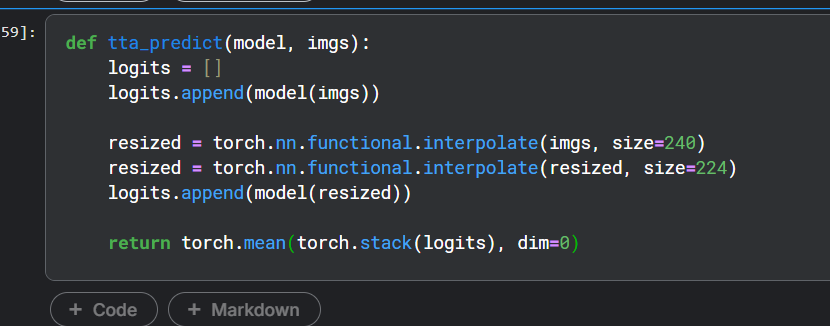
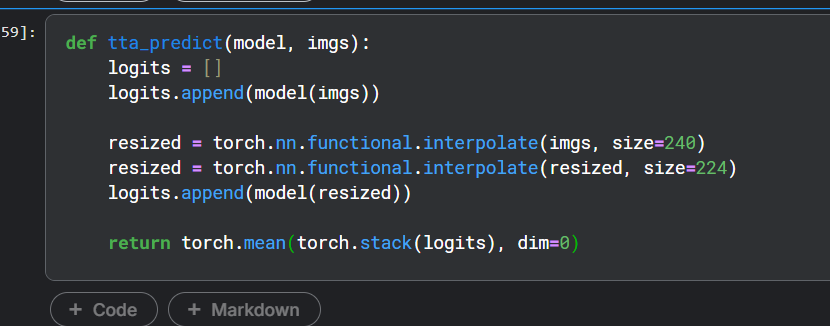
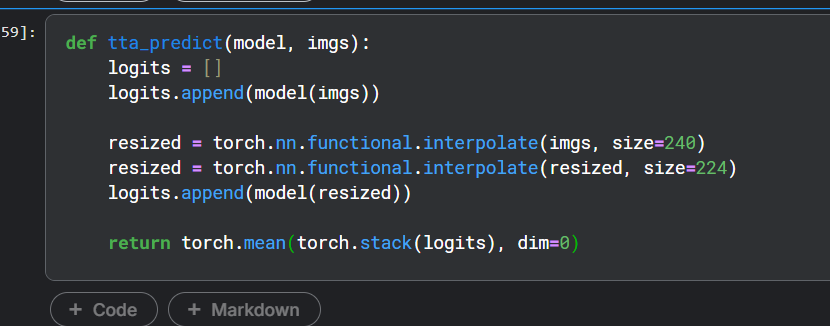

In [29]:
def tta_predict(model, imgs):
    logits = []
    logits.append(model(imgs))

    resized = torch.nn.functional.interpolate(imgs, size=240)
    resized = torch.nn.functional.interpolate(resized, size=224)
    logits.append(model(resized))

    return torch.mean(torch.stack(logits), dim=0)

# **🧪 Final Test Inference with Ensemble + TTA**

In this step, we perform final inference on the test dataset using:

- Ensemble of ResNet18 & ResNet50

- Test-Time Augmentation (TTA)

- No-gradient inference for efficiency

**Predictions from both models are averaged to improve robustness, and the final class is selected using argmax.**

In [30]:
test_preds = []

with torch.no_grad():
    for imgs in test_loader:
        imgs = imgs.to(device)

        out18 = tta_predict(model18, imgs)
        out50 = tta_predict(model50, imgs)

        out = 0.5 * out18 + 0.5 * out50
        preds = out.argmax(1)

        test_preds.extend(preds.cpu().numpy())

# **📤 Submission File Generation**

**In this final step, we generate the submission CSV file in the exact format required by the Kaggle competition.**

- The official sample_submission.csv is used as a template

- Predicted posture labels are inserted into the class_id column

- The file is saved as submissionfile.csv and is ready for upload

In [31]:
sub = pd.read_csv(BASE + "/sample_submission.csv")
sub["class_id"] = test_preds
sub.to_csv("submissionfile.csv", index=False)

print("submissionfile.csv generated successfully")

submissionfile.csv generated successfully


# **🐖 Single Pig Posture Prediction (Ensemble + TTA)**

This helper function predicts the posture of a single pig crop using a ResNet18 + ResNet50 ensemble combined with Test-Time Augmentation (TTA).

# **🔍 What happens here?**

- The pig crop is preprocessed using test-time transforms

- Predictions are generated independently by ResNet18 and ResNet50

- Outputs are averaged (ensemble) for better generalization

- Softmax probabilities are used to compute confidence scores

In [32]:
def predict_pig(pig_img):
    """
    Predict posture for a single pig crop using
    ResNet18 + ResNet50 ensemble with TTA.
    """

    pig_tensor = test_tfms(pig_img).unsqueeze(0).to(device)

    with torch.no_grad():
        out18 = tta_predict(model18, pig_tensor)
        out50 = tta_predict(model50, pig_tensor)

        # Ensemble
        out = 0.5 * out18 + 0.5 * out50
        probs = torch.softmax(out, dim=1)

        conf, pred = torch.max(probs, dim=1)

    return pred.item(), conf.item()

# **🖼️ Test Image Visualization with Predicted Pig Postures**

This function visualizes a single test image by:

- Drawing bounding boxes around each pig

- Predicting posture independently per pig

- Displaying predicted class + confidence score

- Enabling qualitative inspection of model performance

**It is especially useful for debugging, model sanity checks, and presentation-quality outputs.**
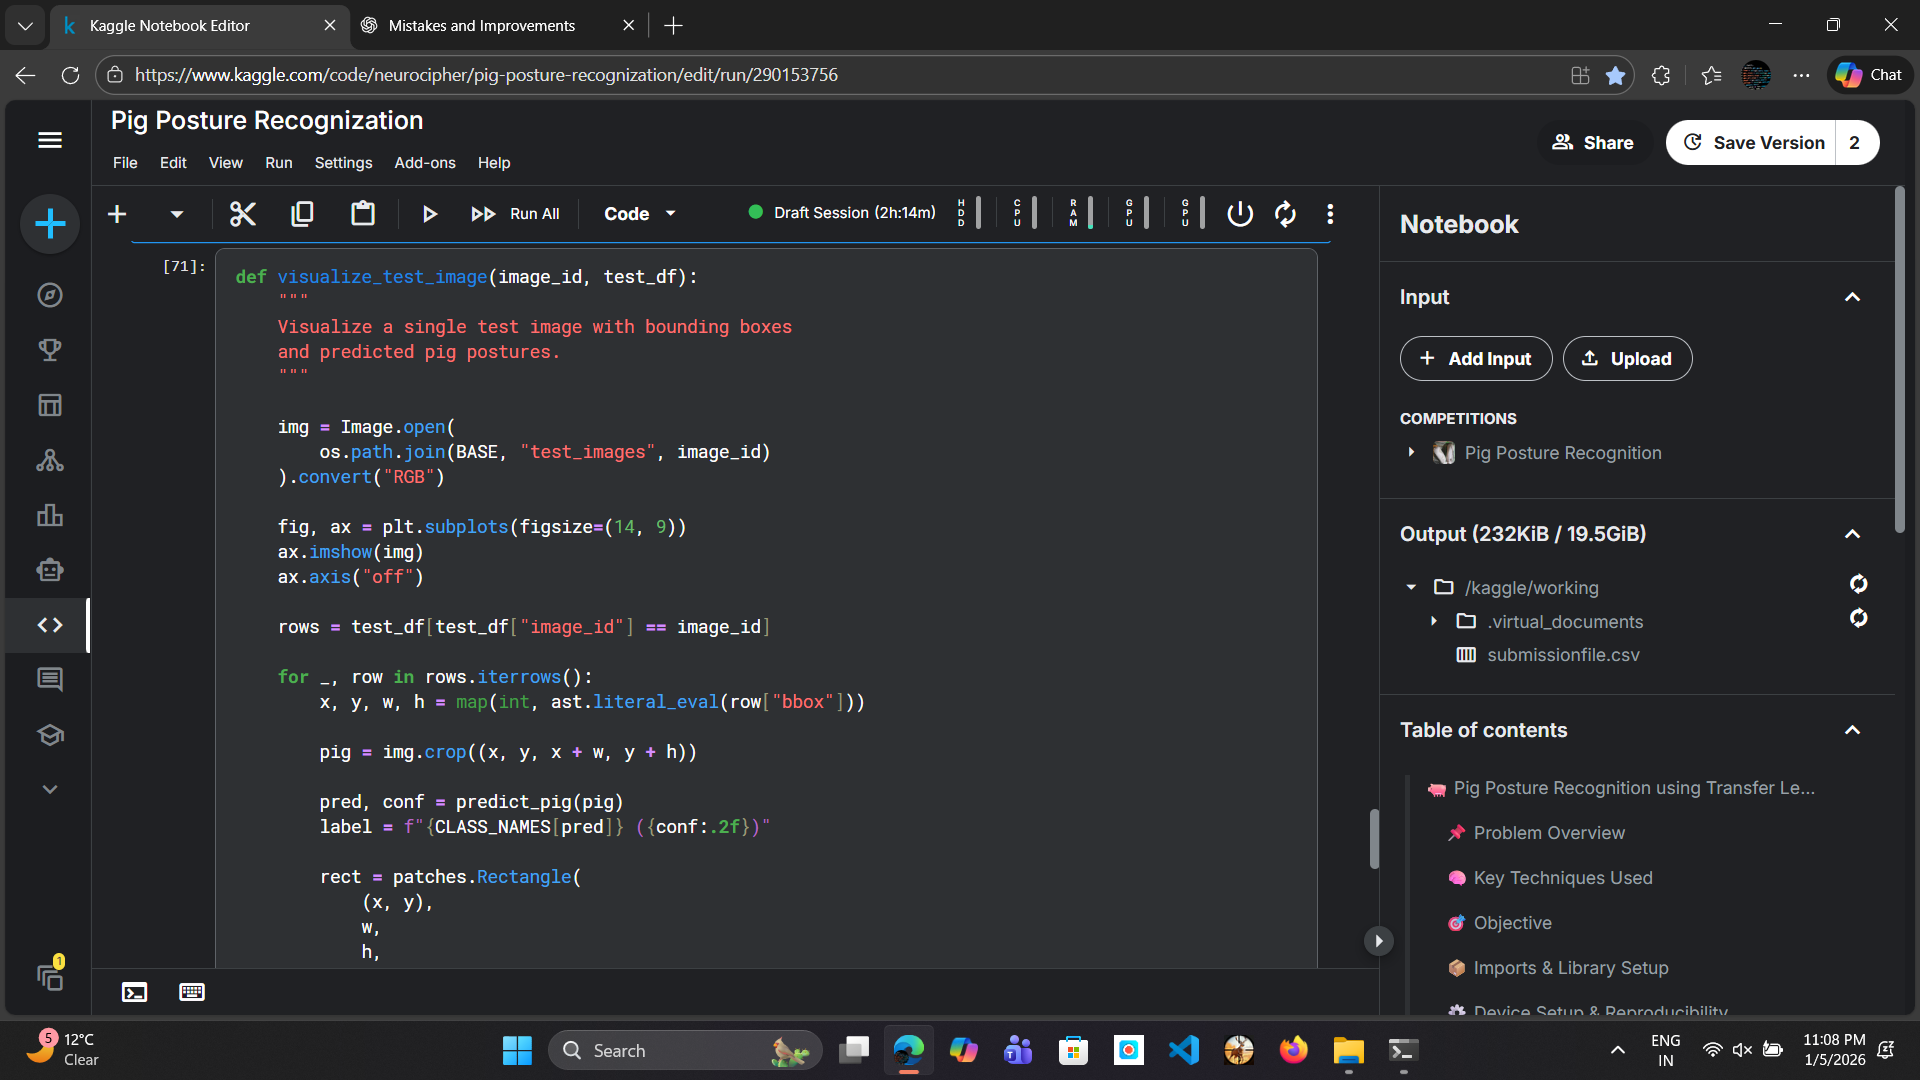

In [33]:
def visualize_test_image(image_id, test_df):
    """
    Visualize a single test image with bounding boxes
    and predicted pig postures.
    """

    img = Image.open(
        os.path.join(BASE, "test_images", image_id)
    ).convert("RGB")

    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(img)
    ax.axis("off")

    rows = test_df[test_df["image_id"] == image_id]

    for _, row in rows.iterrows():
        x, y, w, h = map(int, ast.literal_eval(row["bbox"]))

        pig = img.crop((x, y, x + w, y + h))

        pred, conf = predict_pig(pig)
        label = f"{CLASS_NAMES[pred]} ({conf:.2f})"

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            x,
            y - 5,
            label,
            color="red",
            fontsize=10,
            fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.7)
        )

    plt.show()

# **🔍 Qualitative Evaluation on Random Test Images**

This function performs qualitative analysis by visualizing predictions on five randomly selected test images.

For each image:

- All pigs are detected using provided bounding boxes

- Each pig is cropped and classified independently

- The predicted posture label and confidence score are displayed

- Results are rendered with clear red bounding boxes

This step is crucial for:

- Verifying model correctness

- Detecting systematic misclassifications

- Ensuring left/right posture consistency

- Improving trust and interpretability of the model

**🧠 Models are explicitly switched to evaluation mode to ensure deterministic behavior.**

In [34]:
def visualize_5_test_images():
    """
    Visualize predictions on 5 random test images.
    Each pig is shown with its bounding box and predicted posture.
    """

    # Load test annotations
    test_df = pd.read_csv(BASE + "/test.csv")

    # Unique test image IDs
    image_ids = test_df["image_id"].unique()

    # Safety check
    if len(image_ids) < 5:
        raise ValueError("Less than 5 test images available.")

    # Randomly select 5 images
    selected_images = random.sample(list(image_ids), 5)

    # Set models to eval mode
    model18.eval()
    model50.eval()

    # Visualize each image
    for i, img_id in enumerate(selected_images, 1):
        print(f"\n[{i}/5] Visualizing image: {img_id}")
        visualize_test_image(img_id, test_df)


[1/5] Visualizing image: 00002819.jpg


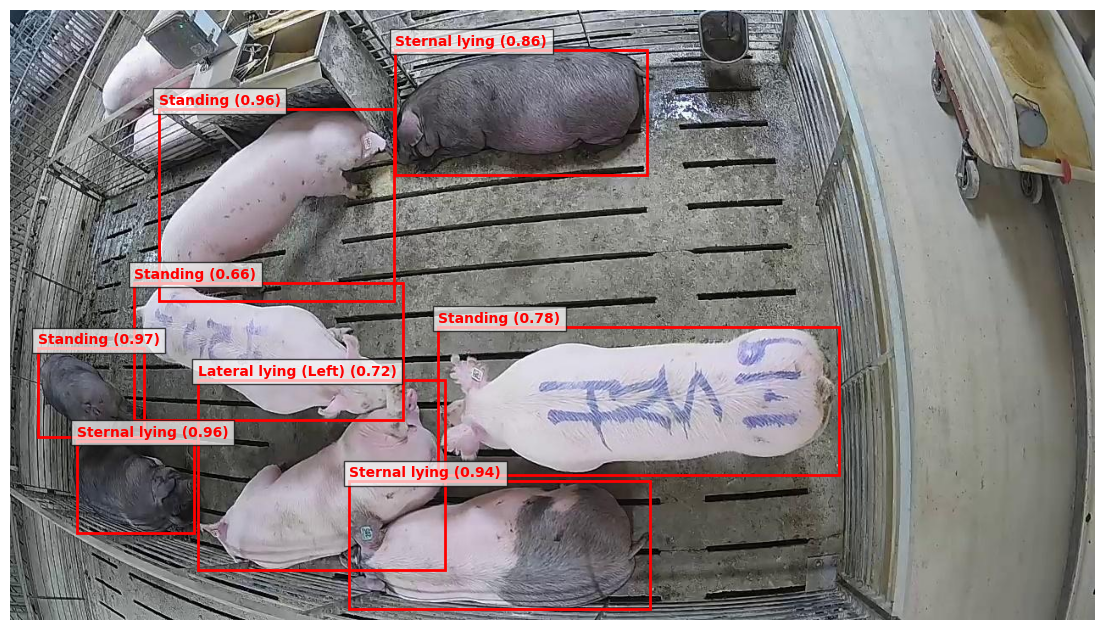


[2/5] Visualizing image: 00002279.jpg


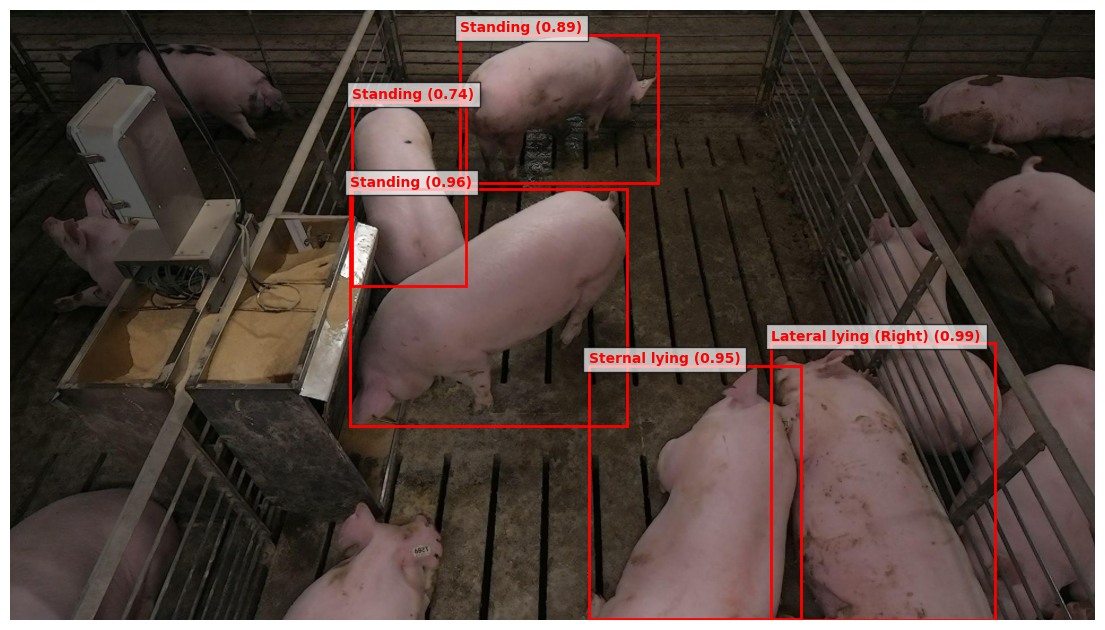


[3/5] Visualizing image: 00002190.jpg


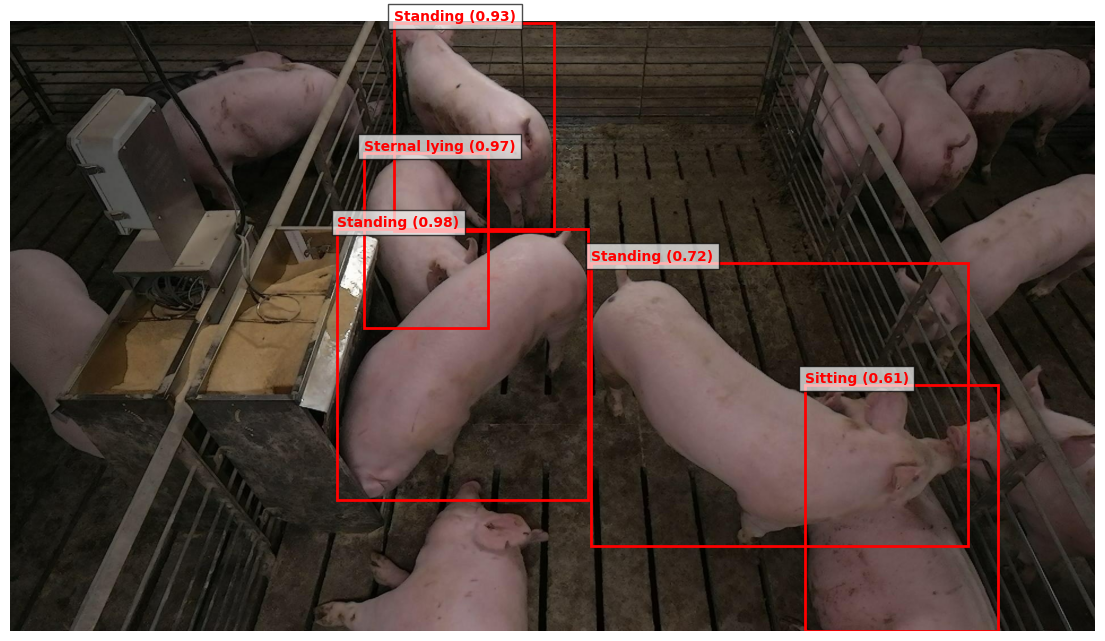


[4/5] Visualizing image: 00002924.jpg


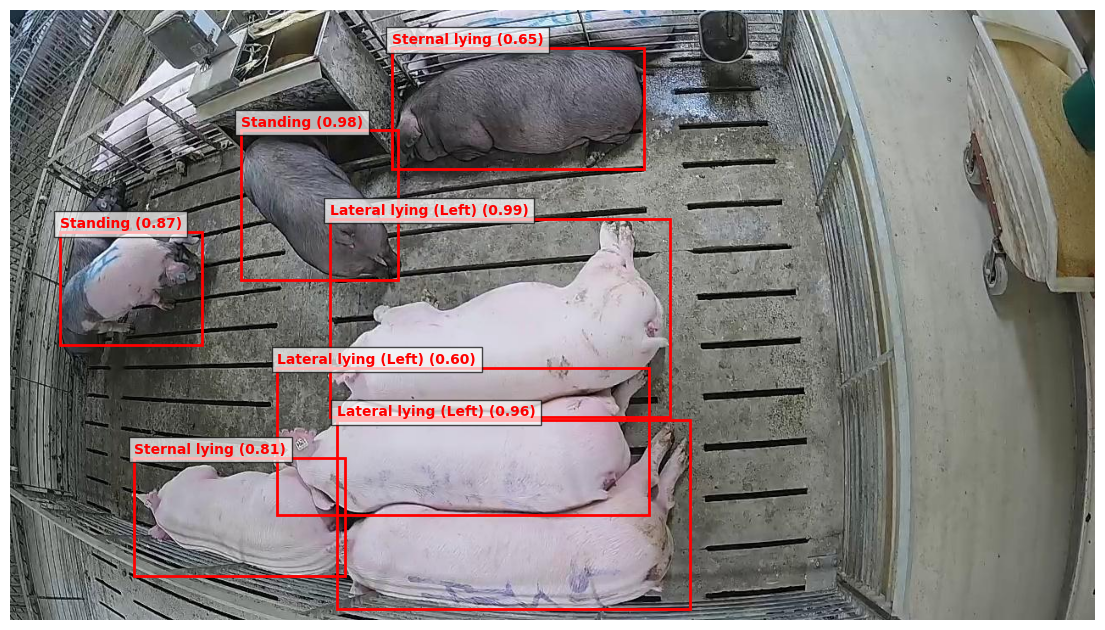


[5/5] Visualizing image: 00002446.jpg


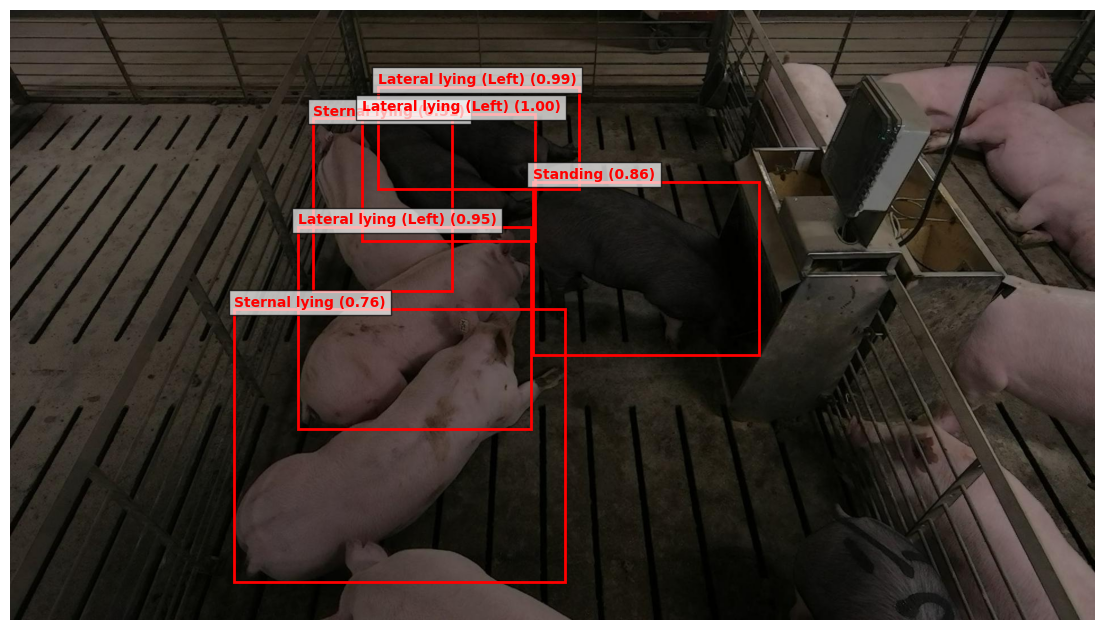

In [35]:
visualize_5_test_images()

# **Thank You :)**